# **Lab 8 - Gaussian Process Regression (GPR)**


Gaussian Process Regression is a nonparametric technique that uses Gaussian Processes to fit data, make predictions and estimate uncertainties. It can be also understood as a "statistical version" of the so-called *kernel methods*.

## Noiseless case

The idea is very simple. Let $f:\Omega\subset\mathbb{R}^{d}\to\mathbb{R}$ be the (unknown) map that we are willing to learn. Let $Z$ be a Gaussian Process over $\Omega$ with mean $\mu=\mu(\mathbf{x})$ and covariance kernel $K=K(\mathbf{x},\mathbf{x}')$. As we have seen in the first part of the course, one can use $Z$ to generate random functions from $\Omega\to\mathbb{R}$. Consequently, **the Gaussian Process defines a probability measure over the space of functions**. More precisely, if $\int_{\Omega}K(\mathbf{x},\mathbf{x})d\mathbf{x}<+\infty$, then one can prove that the realizations of $Z$ are almost surely functions in $L^{2}(\Omega)$. In particular, $Z$ introduces a probability measure over $L^{2}(\Omega)$. Additionally, if $\Omega$ is bounded and $K$ is Lipschitz, then one can actually prove that $Z$ almost surely returns continuous outputs: that is, $Z$ induces a probability measure $\mathbb{P}$ over $\mathcal{C}(\Omega)$, the space of continuous functions.
</br>
</br>
Having this in our mind, consider now the case in which we are given access to some pointwise observations of $f$, namely

$$\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}\quad\text{with}\quad y_i=f(\mathbf{x}_i).$$

We can use this information to update our knowledge about the Gaussian Process. In fact, we can consider the original probability distribution induced by $Z$ as **a prior distribution**, which we can now condition on this observations via Bayes's rule. This will provide us with a novel distribution over $\mathcal{C}(\Omega)$ that we can use to make predictions.

Luckily for us, this conditioning is straightforward thanks to the properties of Gaussian processes. In fact, conditioning $Z$ over the data $D=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N}$ simply results in a new Gaussian process $\tilde{Z}:=Z\;|\;D$ with mean $\tilde{\mu}$,

$$\tilde{\mu}(\mathbf{x})=\mu(\mathbf{x}) + \mathbf{k}_D(\mathbf{x})^\top\mathbf{K}_{D}^{-1}(\boldsymbol{y}-\boldsymbol{\mu}_D),$$

and covariance kernel $\tilde{K}$,

$$\tilde{K}(\mathbf{x},\mathbf{x}')=K(\mathbf{x},\mathbf{x}')-\mathbf{k}_D(\mathbf{x})^\top\mathbf{K}_{D}^{-1}\mathbf{k}_D(\mathbf{x}').$$

Here,

- $\mathbf{K}_{D}\in\mathbb{R}^{N\times N}$ is the matrix whose $i,j$ entry is $K(\mathbf{x}_i,\mathbf{x}_j)$,

- $\mathbf{k}_{D}(\mathbf{x})=[K(\mathbf{x},\mathbf{x}_1),\dots,K(\mathbf{x},\mathbf{x}_{N})]^\top$,


- $\boldsymbol{\mu}_D:=[\mu(\mathbf{x}_1),\dots,\mu(\mathbf{x}_{N})]^\top$,

- $\boldsymbol{y}_D:=[y_1,\dots,y_{N}]^\top$.

## Practical implementation

From a practical stand point, we can directly work with vectors and matrices. Indeed, the above properties all come from a simple fact holding in arbitrary finite-dimensional contexts: if a vector $[Y_*,Y]\in\mathbb{R}^{n+N}$ is Gaussian, then so are its subvectors $Y_*\in\mathbb{R}^{n}$, $Y\in\mathbb{R}^{N}$, and so is the conditional vector $Y_*|Y=\boldsymbol{y}\in\mathbb{R}^{n}$ for every $\boldsymbol{y}\in\mathbb{R}^N$.

How does this translate to our setting? Let $\mathbf{x}^*_1,\dots,\mathbf{x}^*_n$ be points where we want to predict the values of the GP, conditional on the observed data.
Set $Y_*=[Z(\mathbf{x}^*_1),\dots,Z(\mathbf{x}^*_n)]^\top$ and $Y=[Z(\mathbf{x}_1),\dots,Z(\mathbf{x}_N)]^\top$. Then, predicting $Z$ at the points $\mathbf{x}_j^*$ given the data is equivalent to predicting $Y_*$ given $Y=\boldsymbol{y}$. As we mentioned, the conditional probability of $Y_*$ given  $Y=\boldsymbol{y}$ is a multivariate normal. It's mean and covariance matrix are, respectively,

$$\boldsymbol{\mu}_{Y_*|Y=\boldsymbol{y}}=\boldsymbol{\mu}_{Y_*}+\Sigma_{YY_*}^\top\Sigma_{YY}^{-1}(\boldsymbol{y}-\boldsymbol{\mu}_{Y}),\quad\quad\Sigma_{Y_*|Y=\boldsymbol{y}}=\Sigma_{Y_*Y_*}-\Sigma_{YY_*}^\top\Sigma_{YY}^{-1}\Sigma_{YY_*}.$$

<mark>**Exercise 1**</mark></br>
Write a function called $\textsf{GPpredict}$ that, given

- a list (array) of prediction points $[\mathbf{x}_1^*,\dots,\mathbf{x}_n^*]^\top$,
- a list (array) of observation points $[\mathbf{x}_1,\dots,\mathbf{x}_N]^\top$ and corresponding $f$ values $[y_1,\dots,y_N]^\top$,
- a prior distribution for the GP given in terms of an isotropic covariance kernel function $\kappa=\kappa(r)$ and a mean function $\mu=\mu(\mathbf{x})$,

returns a prediction for $f(\mathbf{x}_{1}^*),\dots,f(\mathbf{x}_{n}^*)$ in terms of its conditional mean and covariance matrix.

In [1]:
import numpy as np
from scipy.linalg import solve

In [6]:
def GPpredict(x, xdata, ydata, kernel, mu = lambda x: 0.0*x):
  """
  Input:
    x     (numpy.ndarray)   array of shape (n, d) listing n points with d coordinates where
                            the prediction is to be carried out.

    xdata (numpy.ndarray)   array of shape (N, d) listing N points with d coordinates where
                            function values have been observed.

    ydata (numpy.ndarray)   array of shape (N,) listing the function values at the observation
                            points.

    kernel (function)       function kernel=kernel(r) describing a given isotropic kernel, i.e.,
                            assuming K(x,x') = kernel(|x-x'|).

    mu (function)           function mu=mu(x) returning a mean value for every given point.

  Output:
    mu_prediction           conditional mean at the points x.
    sigma_prediction        conditional covariance matrix at the points x.
  """

  nd = len(xdata) # Data
  ns = len(x) # Prediction
  nall = ns + nd
  xall = np.concatenate((xdata, x), axis = 0).reshape(nall, -1) # (ns + nd, d)
  mu_all = mu(xall).reshape(-1) # this is obviously a vector 

  # Getting the distance across all points
  # This results in a (nall, nall, d) tensor
  distances = xall.reshape(nall, 1, -1) - xall.reshape(1, nall, -1)
  distances = np.linalg.norm(distances, axis = -1)
  Sigma_all = kernel(distances)
  Sigma_s = Sigma_all[-ns:, -ns:]   # the last ns rows and columns
  Sigma_d = Sigma_all[:nd, :nd]
  Sigma_sd = Sigma_all[-ns:, :nd]

  mu_s = mu_all[-ns:]
  mu_d = mu_all[:nd]

  # We can now apply the formula directly
  mu_new = mu_s + Sigma_sd @ solve(Sigma_d, ydata - mu_d)
  K_new = Sigma_s - Sigma_sd @ solve(Sigma_d, Sigma_sd.T)   # note how ydata does not appear here...

  return mu_new, K_new

<mark>**Exercise 2**</mark></br>
The following piece of code allows you to generate random observations from the ground truth model

$$f(x)=x\sin(\pi^2 x^2)+\varepsilon(x),\quad\quad x\in[0,1],$$

where $\varepsilon(x)\sim\mathcal{N}(0,\epsilon^2)$ is an external white noise modeling measurement corruption.

- Set $\epsilon\equiv0$, thus considering a noiseless environment. Make $N=8$ random measurements.

- Use the data to fit a GP with $\mu\equiv0$ and $\kappa(r)=\exp(-25r^2)$.</br>Specifically, use the data and the GP to make a prediction over a uniform grid spanning $[0,1]$ (with, e.g., $1000$ subintervals).

- Compare the ground truth model with your predictions. Be sure to include the predicted mean together with the pointwise confidence bands (confidence level = 95%).

- Sample 5 random trajectories from the posterior distribution of the GP (cf. $\textsf{np.random.multivariate\_normal}$).</br> How are the trajectories related to the data?

- Try including more samples. What happens?

- Try setting $\epsilon=0.02$. What happens?

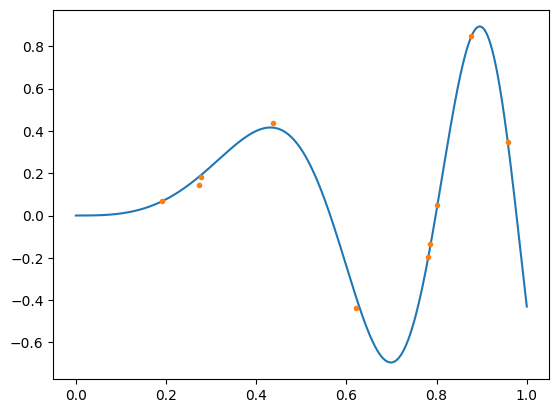

In [33]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x*np.sin((np.pi*x)**2)

np.random.seed(1234)
eps = 0.02

N = 10
xdata = np.random.rand(N)
ydata = f(xdata) + np.random.randn(N)*eps

xgrid = np.linspace(0, 1, 1000)
plt.plot(xgrid, f(xgrid))
plt.plot(xdata, ydata, '.')
axis = plt.gca().axis()
None

In [34]:
# We consider 0 mean and for kernel something that goes 
# like exp(1/sigma**2)
kernel = lambda r: np.exp(-25*r**2)

mu_pred, K_pred = GPpredict(xgrid, xdata, ydata, kernel=kernel)

In [35]:
mu_pred.shape, K_pred.shape

((1000,), (1000, 1000))

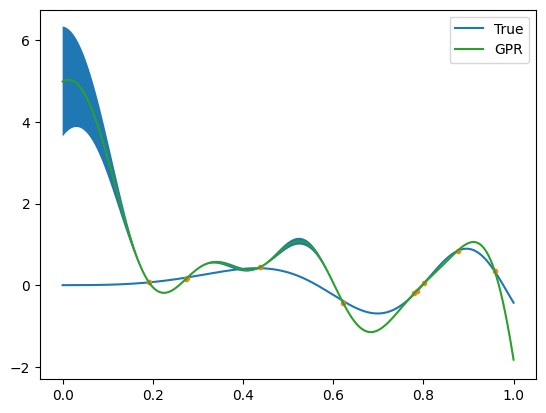

In [36]:
# Variances are just the diagonal of the covariance matrix
sigma_pred = np.maximum(np.diag(K_pred), 0)**0.5

plt.plot(xgrid, f(xgrid), label = 'True')
plt.plot(xdata, ydata, '.')
plt.plot(xgrid, mu_pred, label = 'GPR')
plt.fill_between(xgrid, mu_pred-1.96*sigma_pred, mu_pred + 1.96*sigma_pred)
axis = plt.gca().axis()
plt.legend()
None

However, this is point-wise. We want a confidence interval on the whole trajectory. We can only sample to do this in order to have this empirically.\

Note that GP regression interpolates through the observed points.

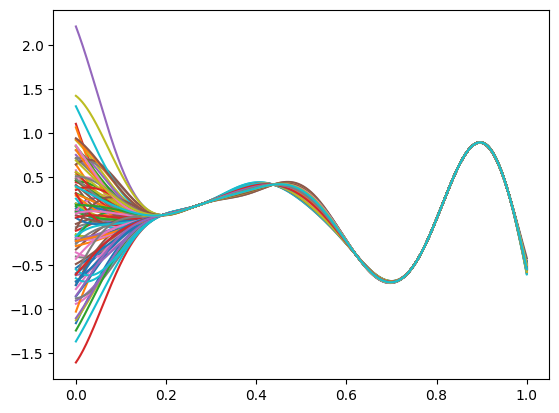

In [ ]:
samples = np.random.multivariate_normal(mean = mu_pred, cov = K_pred, size = 5)
samples.shape

for sample in samples:
    plt.plot(xgrid, sample)

plt.plot(xdata, ydata, 'ok')

## Noisy case

When data is affected by noise, this fact should be accounted for. In fact, if we ignore noise, the GP will always fit the data, considering measurements to be exact.

Luckily, this fact can be fixed easily by letting including a minor modification in the kernel function. Specifically, one replaces the original kernel $K$ with

$$K_{noise}(\mathbf{x},\mathbf{x}')=K(\mathbf{x},\mathbf{x}')+\sigma^{2}\mathbf{1}_{\{0\}}(|\mathbf{x}-\mathbf{x}'|)$$

where $\sigma^{2}$ is a suitable parameter. Ideally $\sigma=\epsilon$, so that the "additional" variance effectively captures the effect of the underlying white noise.

<mark>**Exercise 3**</mark></br>
Consider the example in Exercise 2. Repeat the analysis with $\epsilon=0.02$ but using a noisy-aware kernel with $\sigma=\epsilon$.



In [ ]:
np.random.seed(4)
eps = 0.02

N = 30
xdata = np.random.rand(N)
ydata = f(xdata) + np.random.randn(N)*eps

In [37]:
sigma = 0.02    # variability in the measurements of the apparatus
# Note how cannot actually fix r to be 0
# We can only set a bound
kernel = lambda r: np.exp(-25*r**2) + (sigma**2)*(r < 1e-15)

mu_pred, K_pred = GPpredict(xgrid, xdata, ydata, kernel=kernel)

In [38]:
mu_pred.shape, K_pred.shape

((1000,), (1000, 1000))

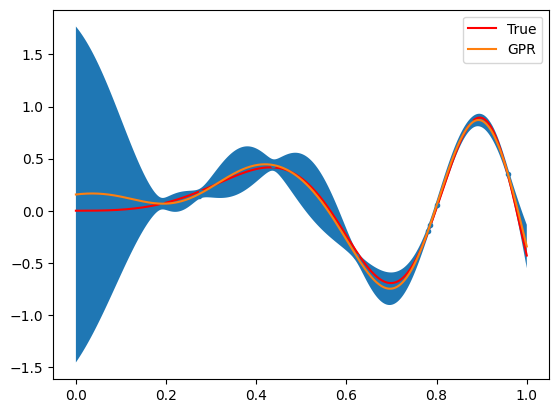

In [41]:
# Variances are just the diagonal of the covariance matrix
sigma_pred = np.maximum(np.diag(K_pred), 0)**0.5

plt.plot(xgrid, f(xgrid), label = 'True', color = "red")
plt.plot(xdata, ydata, '.')
plt.plot(xgrid, mu_pred, label = 'GPR')
plt.fill_between(xgrid, mu_pred-1.96*sigma_pred, mu_pred + 1.96*sigma_pred)
axis = plt.gca().axis()
plt.legend()
None

However, this is point-wise. We want a confidence interval on the whole trajectory. We can only sample to do this in order to have this empirically.\

Note that GP regression interpolates through the observed points.

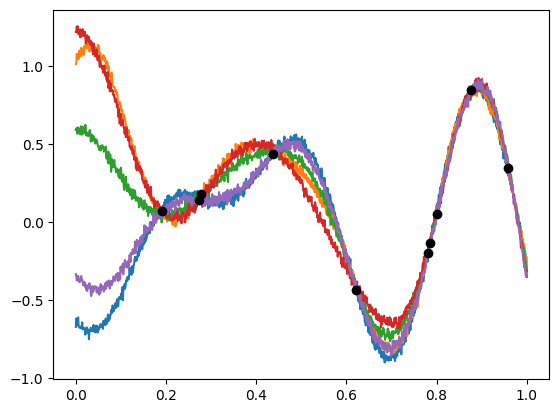

In [40]:
samples = np.random.multivariate_normal(mean = mu_pred, cov = K_pred, size = 5)
samples.shape

for sample in samples:
    plt.plot(xgrid, sample)

plt.plot(xdata, ydata, 'ok')

Consider that we actually need to estimate the parameter in the kernel, and sigma.\
Moreover, we can find packages that estimate those automatically, essentrially through MLE. In the solution, we can see that there is the possibility to express a range for where each constant could lie, and the library will optimize it. 

It is more uncommon to use this for multivariate regression, even though it's possible. (We could just use multiple single regressions). The critical part of this code, in a big data context, is inverting the linear systems to actually retrieve the kernels, which must be done every new batch of observations is presented.

## Scikit-learn implementation

Clearly, all of this is already available in classical Python libraries, featuring optimized routines and hyperparameter tuning. In particular, GPs are also implemented in $\textsf{scikit-learn}$, a package installed under the name "$\textsf{sklearn}$".

<mark>**Exercise 5**</mark></br>
Repeat Exercise 3 using the implementation available in $\textsf{scikit-learn}$.

See:

- sklearn.gaussian_process.GaussianProcessRegressor,
- sklearn.gaussian_process.kernels, specifically RBF, ConstantKernel and WhiteKernel.

Specifically, see if the results are the same when disabling hyperparameter tuning, and see how they change when enabling it. Comment the results.



In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

kernel = ConstantKernel(1.0, "fixed") * RBF(1.0/np.sqrt(50), "fixed") + WhiteKernel(eps**2, "fixed")
gp = GaussianProcessRegressor(kernel=kernel)

gp.fit(xdata.reshape(-1, 1), ydata)
y_pred, sigma = gp.predict(xgrid.reshape(-1, 1), return_std=True)

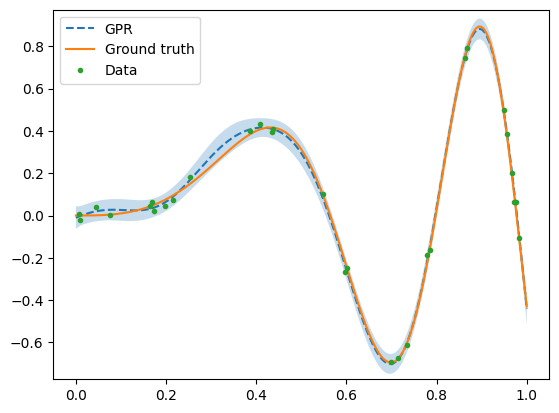

In [ ]:
uncertainties = 1.96*sigma
plt.plot(xgrid, y_pred, '--', label = 'GPR')
plt.plot(xgrid, f(xgrid), label = 'Ground truth')
plt.fill_between(xgrid, y_pred-uncertainties, y_pred + uncertainties, alpha = 0.25)
plt.plot(xdata, ydata, '.', label = 'Data')
plt.axis(axis)
plt.legend()
None

If hyperparameters are not optimized, we get the same results.

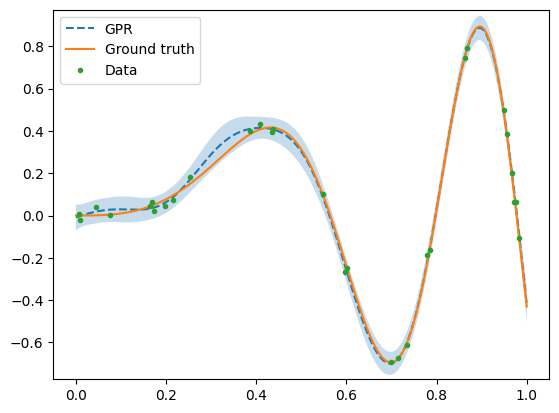

In [ ]:
kernel = ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1.0, (1e-3, 1e3)) + WhiteKernel(1.0, (1e-4, 1e-2))
gp = GaussianProcessRegressor(kernel=kernel)

gp.fit(xdata.reshape(-1, 1), ydata)
y_pred, sigma = gp.predict(xgrid.reshape(-1, 1), return_std=True)

uncertainties = 1.96*sigma
plt.plot(xgrid, y_pred, '--', label = 'GPR')
plt.plot(xgrid, f(xgrid), label = 'Ground truth')
plt.fill_between(xgrid, y_pred-uncertainties, y_pred + uncertainties, alpha = 0.25)
plt.plot(xdata, ydata, '.', label = 'Data')
plt.axis(axis)
plt.legend()
None

If hyperparameters are optimized, the final result can be different (potentially way better if a wrong initial guess is picked!).